# Zomato Restaurant Market Analysis – EDA & Advanced Analysis

## Continuation of SQL Case Study

This notebook continues the original Zomato SQL case study.

The original case study already covers:
- Restaurant pricing
- Data quality
- Online delivery
- Affordable high-performing restaurants
- City-level delivery adoption
- Delivery without table booking
- Cuisine popularity
- City-level dining cost

This continuation adds:
- Exploratory Data Analysis (EDA)
- Data quality analysis
- Restaurant and city profiling
- Customer engagement analysis
- Correlation analysis
- Restaurant segmentation
- Value-for-money analysis
- City opportunity analysis
- Project-defined Market Opportunity Score
- Business insights after every analysis
- Final business recommendations

**Coding approach:** Kept simple and close to the original notebook style using Pandas, SQLite and SQL queries.


## 1. Load the Dataset

Keep `Zomato.xlsx` in the same folder as this notebook.


In [8]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

df = pd.read_excel("Zomato.xlsx")

df.head()


,RestaurantID,RestaurantName,CountryCode,City,Address,Locality,LocalityVerbose,Cuisines,Currency,Has_Table_booking,Has_Online_delivery,Is_delivering_now,Switch_to_order_menu,Price_range,Votes,Average_Cost_for_two,Rating,CountryName
0,6317637,Le Petit Souffle,162,Makati City,Third Floor| Century City Mall| Kalayaan Avenu...,Century City Mall| Poblacion| Makati City,Century City Mall| Poblacion| Makati City| Mak...,French| Japanese| Desserts,Botswana Pula(P),Yes,No,No,No,3,314,1100,4.8,Philippines
1,6304287,Izakaya Kikufuji,162,Makati City,Little Tokyo| 2277 Chino Roces Avenue| Legaspi...,Little Tokyo| Legaspi Village| Makati City,Little Tokyo| Legaspi Village| Makati City| Ma...,Japanese,Botswana Pula(P),Yes,No,No,No,3,591,1200,4.5,Philippines
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,Edsa Shangri-La| 1 Garden Way| Ortigas| Mandal...,Edsa Shangri-La| Ortigas| Mandaluyong City,Edsa Shangri-La| Ortigas| Mandaluyong City| Ma...,Seafood| Asian| Filipino| Indian,Botswana Pula(P),Yes,No,No,No,4,270,4000,4.4,Philippines
3,6318506,Ooma,162,Mandaluyong City,Third Floor| Mega Fashion Hall| SM Megamall| O...,SM Megamall| Ortigas| Mandaluyong City,SM Megamall| Ortigas| Mandaluyong City| Mandal...,Japanese| Sushi,Botswana Pula(P),No,No,No,No,4,365,1500,4.9,Philippines
4,6314302,Sambo Kojin,162,Mandaluyong City,Third Floor| Mega Atrium| SM Megamall| Ortigas...,SM Megamall| Ortigas| Mandaluyong City,SM Megamall| Ortigas| Mandaluyong City| Mandal...,Japanese| Korean,Botswana Pula(P),Yes,No,No,No,4,229,1500,4.8,Philippines


In [9]:
conn = sqlite3.connect(":memory:")

df.to_sql("zomato", conn, if_exists="replace", index=False)

def run(query, label=None):

    if label:
        print(f"=== {label} ===")

    result = pd.read_sql(query, conn)

    display(result)

    return result


## 2. Dataset Overview

Before starting the additional analysis, we will understand the size and structure of the dataset.


In [10]:
q9 = """
select
    count(*) as total_restaurants,
    count(distinct CountryName) as total_countries,
    count(distinct City) as total_cities,
    count(distinct Cuisines) as total_cuisine_combinations
from zomato
"""

q9_result = run(q9, "Q9 - Dataset Overview")


=== Q9 - Dataset Overview ===


,total_restaurants,total_countries,total_cities,total_cuisine_combinations
0,9551,15,141,1825


In [11]:
print("Insight:")
print("This gives the overall scale of the Zomato dataset and helps us understand the geographic and cuisine coverage before deeper analysis.")


Insight:
This gives the overall scale of the Zomato dataset and helps us understand the geographic and cuisine coverage before deeper analysis.


## 3. Data Quality Analysis

Data quality is important because missing ratings, votes and other fields can affect business conclusions.


In [12]:
q10 = """
select
    count(*) as total_rows,
    sum(case when RestaurantName is null then 1 else 0 end) as missing_restaurant_name,
    sum(case when City is null then 1 else 0 end) as missing_city,
    sum(case when Cuisines is null then 1 else 0 end) as missing_cuisines,
    sum(case when Rating is null then 1 else 0 end) as missing_rating,
    sum(case when Votes is null then 1 else 0 end) as missing_votes,
    sum(case when Average_Cost_for_two is null then 1 else 0 end) as missing_cost
from zomato
"""

q10_result = run(q10, "Q10 - Missing Value Analysis")


=== Q10 - Missing Value Analysis ===


,total_rows,missing_restaurant_name,missing_city,missing_cuisines,missing_rating,missing_votes,missing_cost
0,9551,0,0,9,0,0,0


In [13]:
print("Insight:")
print("The missing-value profile shows which fields need attention before calculating restaurant performance or customer-engagement KPIs.")


Insight:
The missing-value profile shows which fields need attention before calculating restaurant performance or customer-engagement KPIs.


In [14]:
q11 = """
select
    sum(case when Rating = 0 then 1 else 0 end) as zero_rating_restaurants,
    sum(case when Votes = 0 then 1 else 0 end) as zero_vote_restaurants,
    sum(case when Rating = 0 or Votes = 0 then 1 else 0 end) as restaurants_with_zero_rating_or_votes
from zomato
"""

q11_result = run(q11, "Q11 - Zero Rating and Zero Vote Analysis")


=== Q11 - Zero Rating and Zero Vote Analysis ===


,zero_rating_restaurants,zero_vote_restaurants,restaurants_with_zero_rating_or_votes
0,0,1094,1094


In [15]:
print("Insight:")
print("Zero ratings or votes should not automatically be interpreted as poor restaurant performance. They can also indicate limited customer engagement or missing review activity.")


Insight:
Zero ratings or votes should not automatically be interpreted as poor restaurant performance. They can also indicate limited customer engagement or missing review activity.


In [16]:
q12 = """
select
    count(*) - count(distinct RestaurantID) as duplicate_restaurant_ids
from zomato
"""

q12_result = run(q12, "Q12 - Duplicate Restaurant ID Check")


=== Q12 - Duplicate Restaurant ID Check ===


,duplicate_restaurant_ids
0,0


In [17]:
print("Insight:")
print("Duplicate Restaurant IDs can lead to double-counting restaurants and should be investigated before reporting restaurant-level KPIs.")


Insight:
Duplicate Restaurant IDs can lead to double-counting restaurants and should be investigated before reporting restaurant-level KPIs.


# 4. Exploratory Data Analysis

## Restaurant Distribution


In [18]:
q13 = """
select
    CountryName,
    count(*) as restaurant_count
from zomato
group by CountryName
order by restaurant_count desc
limit 10
"""

q13_result = run(q13, "Q13 - Top 10 Countries by Restaurant Count")


=== Q13 - Top 10 Countries by Restaurant Count ===


,CountryName,restaurant_count
0,India,8652
1,United States,434
2,England,80
3,United Arab Emirates,60
4,South Africa,60
5,Brazil,60
6,New Zealand,40
7,Turkey,34
8,Australia,24
9,Philippines,22


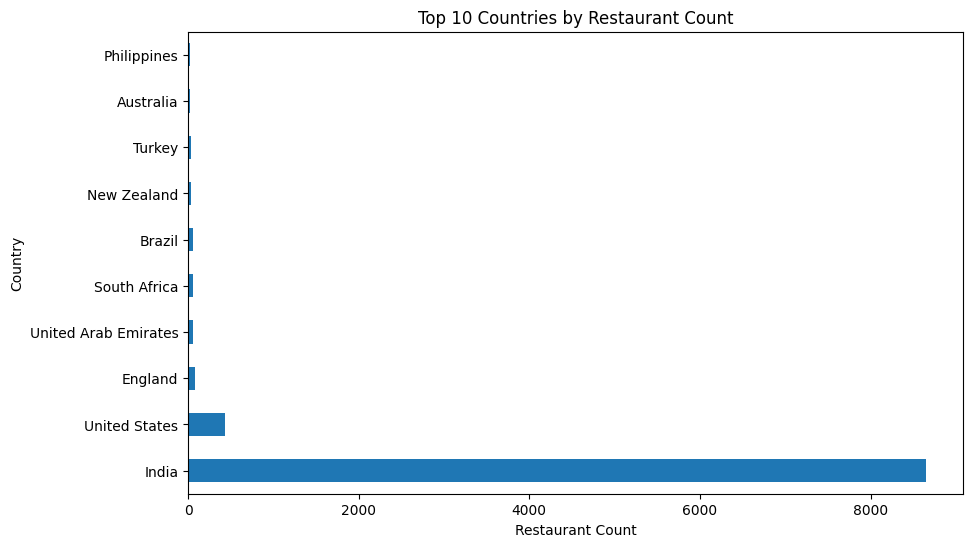

In [19]:
q13_result.set_index("CountryName")["restaurant_count"].plot(kind="barh", figsize=(10,6))
plt.title("Top 10 Countries by Restaurant Count")
plt.xlabel("Restaurant Count")
plt.ylabel("Country")
plt.show()


In [20]:
print("Insight:")
print("The country distribution shows where the dataset is concentrated. This is important because global results may be heavily influenced by countries with more restaurant records.")


Insight:
The country distribution shows where the dataset is concentrated. This is important because global results may be heavily influenced by countries with more restaurant records.


In [21]:
q14 = """
select
    City,
    CountryName,
    count(*) as restaurant_count
from zomato
group by City, CountryName
order by restaurant_count desc
limit 15
"""

q14_result = run(q14, "Q14 - Top 15 Cities by Restaurant Count")


=== Q14 - Top 15 Cities by Restaurant Count ===


,City,CountryName,restaurant_count
0,New Delhi,India,5473
1,Gurgaon,India,1118
2,Noida,India,1080
3,Faridabad,India,251
4,Ghaziabad,India,25
5,Ahmedabad,India,21
6,Amritsar,India,21
7,Bhubaneshwar,India,21
8,Guwahati,India,21
9,Lucknow,India,21


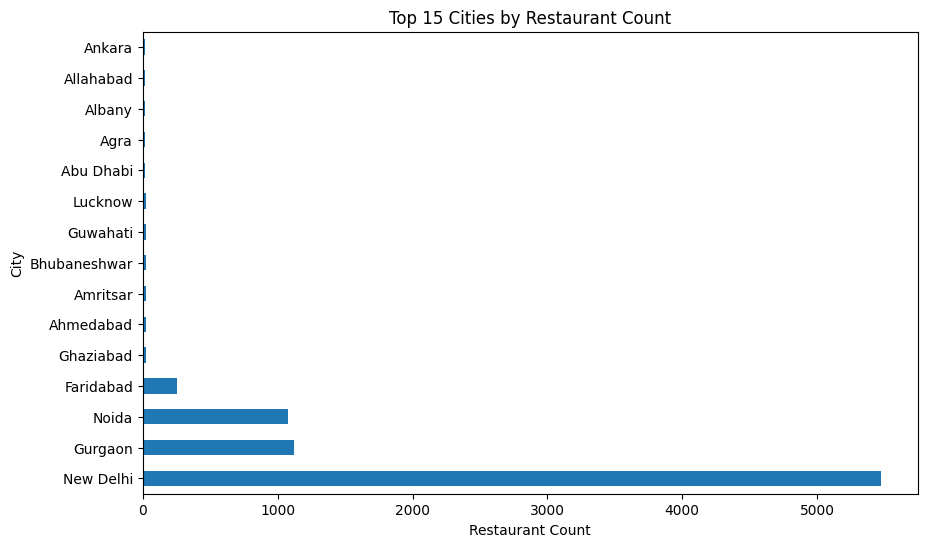

In [22]:
q14_result.set_index("City")["restaurant_count"].plot(kind="barh", figsize=(10,6))
plt.title("Top 15 Cities by Restaurant Count")
plt.xlabel("Restaurant Count")
plt.ylabel("City")
plt.show()


In [23]:
print("Insight:")
print("Cities with a high number of listed restaurants represent larger restaurant markets in this dataset and provide a useful base for comparing delivery, pricing and customer engagement.")


Insight:
Cities with a high number of listed restaurants represent larger restaurant markets in this dataset and provide a useful base for comparing delivery, pricing and customer engagement.


## Rating and Pricing Analysis


In [24]:
q15 = """
select
    case
        when Rating = 0 or Rating is null then 'Not Rated'
        when Rating < 2 then 'Below 2'
        when Rating < 3 then '2 - 2.9'
        when Rating < 4 then '3 - 3.9'
        when Rating < 4.5 then '4 - 4.4'
        else '4.5 - 5'
    end as rating_band,
    count(*) as restaurant_count
from zomato
where CountryName = 'India'
group by rating_band
order by restaurant_count desc
"""

q15_result = run(q15, "Q15 - Restaurant Rating Distribution")


=== Q15 - Restaurant Rating Distribution ===


,rating_band,restaurant_count
0,3 - 3.9,4282
1,Below 2,2142
2,2 - 2.9,1420
3,4 - 4.4,692
4,4.5 - 5,116


In [25]:
print("Insight:")
print("The Indian restaurant market is heavily concentrated around mid-range ratings, while highly rated restaurants represent a much smaller segment.")


Insight:
The Indian restaurant market is heavily concentrated around mid-range ratings, while highly rated restaurants represent a much smaller segment.


In [26]:
q16 = """
select
    Price_range,
    count(*) as restaurant_count,
    round(avg(Rating),2) as average_rating,
    round(avg(Votes),0) as average_votes,
    round(avg(Average_Cost_for_two),2) as average_cost
from zomato
where CountryName = 'India'
group by Price_range
order by Price_range
"""

q16_result = run(q16, "Q16 - Price Range vs Rating, Votes and Cost in India")


=== Q16 - Price Range vs Rating, Votes and Cost in India ===


,Price_range,restaurant_count,average_rating,average_votes,average_cost
0,1,4295,2.33,36.0,284.38
1,2,2858,2.99,133.0,620.13
2,3,1111,3.60,444.0,1257.88
3,4,388,3.66,404.0,2582.86


In [27]:
print("Insight:")
print("Higher price segments generally show higher ratings and engagement, but the Indian market is heavily concentrated in the lowest price range.")


Insight:
Higher price segments generally show higher ratings and engagement, but the Indian market is heavily concentrated in the lowest price range.


## Online Delivery Analysis


In [85]:
q17 = """
SELECT
    City,
    COUNT(*) AS total_restaurants,
    SUM(CASE WHEN Has_Online_delivery = 'Yes' THEN 1 ELSE 0 END) AS online_delivery_count,
    ROUND(
        SUM(CASE WHEN Has_Online_delivery = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
        2
    ) AS online_delivery_percentage
FROM zomato
WHERE CountryName = 'India'
GROUP BY City
HAVING COUNT(*) >= 10 AND online_delivery_count > 0
ORDER BY online_delivery_percentage DESC
"""
q17_result = run(q17, "Q17 - Top 10 Cities by Online Delivery Adoption")

=== Q17 - Top 10 Cities by Online Delivery Adoption ===


,City,total_restaurants,online_delivery_count,online_delivery_percentage
0,Chennai,20,13,65.00
1,Ahmedabad,21,11,52.38
2,Nagpur,20,10,50.00
3,Jaipur,20,10,50.00
4,Kolkata,20,8,40.00
5,Ghaziabad,25,10,40.00
6,Hyderabad,18,7,38.89
7,Gurgaon,1118,425,38.01
8,Pune,20,7,35.00
9,Mumbai,20,7,35.00


In [87]:
print("Insight:")
print("The online delivery percentages show strong adoption in several Indian cities, with Chennai leading at 65%. This indicates a vibrant online food delivery market in these regions.")

Insight:
The online delivery percentages show strong adoption in several Indian cities, with Chennai leading at 65%. This indicates a vibrant online food delivery market in these regions.


In [88]:
q18 = """
select
    Price_range,
    count(*) as total_restaurants,
    sum(case when Has_Online_delivery = 'Yes' then 1 else 0 end) as delivery_restaurants,
    round(
        sum(case when Has_Online_delivery = 'Yes' then 1 else 0 end) * 100.0 / count(*),
        2
    ) as delivery_percentage
from zomato
where CountryName = 'India'
group by Price_range
order by Price_range
"""

q18_result = run(q18, "Q18 - Online Delivery Adoption by Price Range in India")


=== Q18 - Online Delivery Adoption by Price Range in India ===


,Price_range,total_restaurants,delivery_restaurants,delivery_percentage
0,1,4295,701,16.32
1,2,2858,1281,44.82
2,3,1111,398,35.82
3,4,388,43,11.08


In [89]:
print("Insight:")
print("Online delivery adoption is highest among mid-priced restaurants (Price Range 2 and 3), while both the lowest- and highest-priced segments show lower adoption.")


Insight:
Online delivery adoption is highest among mid-priced restaurants (Price Range 2 and 3), while both the lowest- and highest-priced segments show lower adoption.


## Customer Engagement Analysis


In [32]:
q19 = """
select
    City,
    count(*) as restaurant_count,
    sum(Votes) as total_votes,
    round(avg(Votes),0) as average_votes,
    round(avg(Rating),2) as average_rating
from zomato
where CountryName = 'India'
group by City
having count(*) >= 10
order by total_votes desc
limit 10
"""

q19_result = run(q19, "Q19 - Top 10 Indian Cities by Customer Votes")


=== Q19 - Top 10 Indian Cities by Customer Votes ===


,City,restaurant_count,total_votes,average_votes,average_rating
0,New Delhi,5473,628340,115.0,2.70
1,Gurgaon,1118,132160,118.0,2.86
2,Noida,1080,73488,68.0,2.39
3,Bangalore,20,56115,2806.0,4.38
4,Kolkata,20,44593,2230.0,4.25
5,Mumbai,20,29697,1485.0,4.08
6,Chennai,20,27695,1385.0,4.31
7,Hyderabad,18,24135,1341.0,4.34
8,Pune,20,20732,1037.0,4.22
9,Goa,20,15098,755.0,4.25


In [90]:
print("Insight:")
print("New Delhi leads in total customer engagement because of its huge restaurant base, but smaller markets show much stronger engagement and ratings per restaurant.")


Insight:
New Delhi leads in total customer engagement because of its huge restaurant base, but smaller markets show much stronger engagement and ratings per restaurant.


In [34]:
q20 = """
select
    case
        when Votes = 0 then '0 votes'
        when Votes < 100 then '1 - 99'
        when Votes < 500 then '100 - 499'
        when Votes < 1000 then '500 - 999'
        else '1000+'
    end as vote_band,
    count(*) as restaurant_count,
    round(avg(Rating),2) as average_rating
from zomato
where CountryName = 'India'
group by vote_band
order by restaurant_count desc
"""

q20_result = run(q20, "Q20 - Restaurant Engagement Distribution by Vote Band")


=== Q20 - Restaurant Engagement Distribution by Vote Band ===


,vote_band,restaurant_count,average_rating
0,1 - 99,5385,2.74
1,100 - 499,1673,3.64
2,0 votes,1093,1.00
3,500 - 999,266,3.94
4,1000+,235,4.11


In [91]:
print("Insight:")
print("Restaurants with higher customer engagement tend to have higher average ratings, while the majority of restaurants have very limited customer interaction.")


Insight:
Restaurants with higher customer engagement tend to have higher average ratings, while the majority of restaurants have very limited customer interaction.


## Cuisine Analysis


In [36]:
q21 = """
select
    Cuisines,
    count(*) as restaurant_count,
    sum(Votes) as total_votes,
    round(avg(Rating),2) as average_rating
from zomato
where Cuisines is not null and CountryName = 'India'
group by Cuisines
order by total_votes desc
limit 15
"""

q21_result = run(q21, "Q21 - Top 15 Cuisine Combinations by Customer Votes")


=== Q21 - Top 15 Cuisine Combinations by Customer Votes ===


,Cuisines,restaurant_count,total_votes,average_rating
0,North Indian| Mughlai,334,53747,3.01
1,North Indian,936,46241,2.15
2,North Indian| Chinese,511,42012,2.64
3,Cafe,279,25464,2.97
4,North Indian| Mughlai| Chinese,197,20115,2.74
5,Chinese,340,19046,2.34
6,Fast Food,348,17098,2.45
7,South Indian,111,16223,2.64
8,Mughlai| North Indian,60,15275,2.46
9,European| Mediterranean| North Indian,3,12541,4.80


In [37]:
print("Insight:")
print("High total votes indicate strong recorded customer engagement with these cuisine combinations and can support cuisine-focused promotions or discovery strategies.")


Insight:
High total votes indicate strong recorded customer engagement with these cuisine combinations and can support cuisine-focused promotions or discovery strategies.


# 5. Correlation Analysis

Correlation can help identify relationships between rating, votes, price range and average cost.

**Note:** Correlation shows association, not causation.


In [38]:
correlation = df[
    ["Rating", "Votes", "Average_Cost_for_two", "Price_range"]
].corr()


correlation.round(2)

,Rating,Votes,Average_Cost_for_two,Price_range
Rating,1.00,0.35,0.06,0.46
Votes,0.35,1.00,0.07,0.31
Average_Cost_for_two,0.06,0.07,1.00,0.08
Price_range,0.46,0.31,0.08,1.00


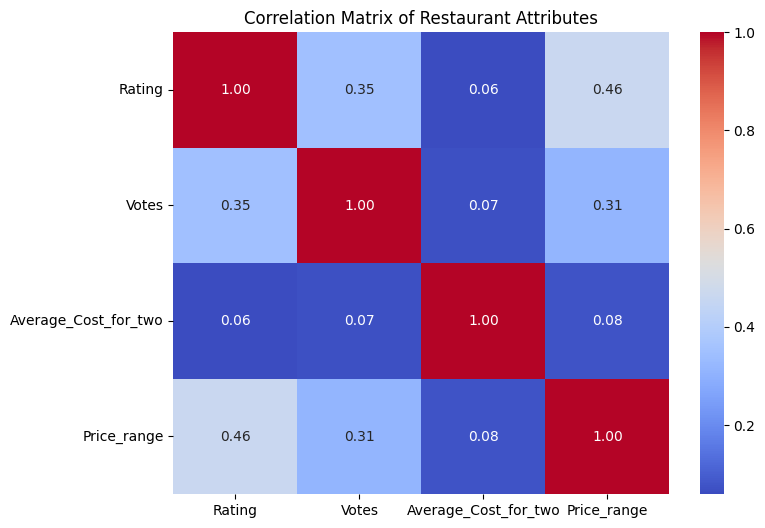

In [39]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Restaurant Attributes')
plt.show()



The original output was misleading for interpreting the business relationship because different currencies were being compared together.

This was a good reminder that before interpreting a statistical result, I need to validate whether the underlying data is comparable.

In [40]:
df_india = df[df['CountryName'] == 'India']
correlation = df_india[
    ["Rating", "Votes", "Average_Cost_for_two", "Price_range"]
].corr()


correlation.round(2)


,Rating,Votes,Average_Cost_for_two,Price_range
Rating,1.00,0.32,0.36,0.43
Votes,0.32,1.00,0.28,0.31
Average_Cost_for_two,0.36,0.28,1.00,0.84
Price_range,0.43,0.31,0.84,1.00


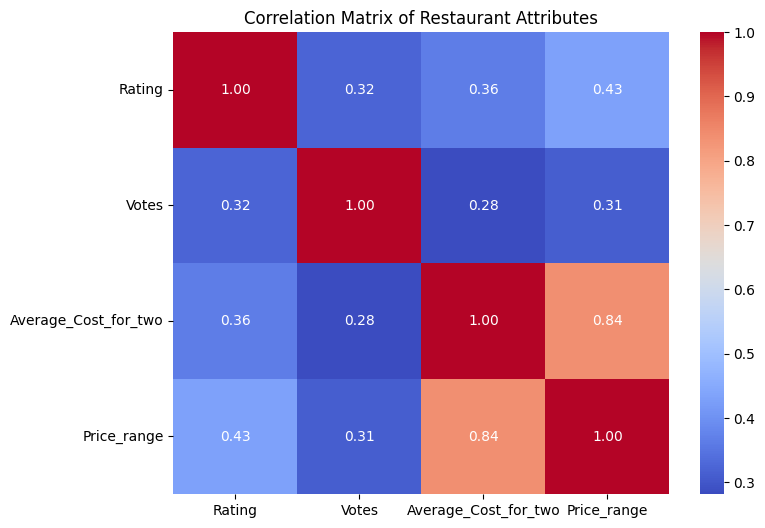

In [41]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Restaurant Attributes')
plt.show()

Once the analysis was **restricted to India**, the relationship between actual cost and price range became much clearer.

This suggests that analysing data within a consistent market and currency context can reveal relationships that were hidden in the unfiltered dataset.

And importantly, **0.84** shows **a strong association — not causation.**

# 6. Restaurant Segmentation

We will create simple business-oriented segments using rating, votes and average cost.

The thresholds are project-defined for this case study and are not official Zomato classifications.


In [43]:
q22 = """
select
    RestaurantName,
    City,
    Rating,
    Votes,
    Average_Cost_for_two,
    case
        when Rating >= 4.5
             and Votes > 500
             and Average_Cost_for_two < 800
            then 'High Value Performer'

        when Rating >= 4
             and Votes >= 200
            then 'Strong Performer'

        when Rating >= 3
            then 'Average Performer'

        else 'Needs Attention'
    end as restaurant_segment
from zomato
where CountryName = 'India'
order by Rating desc, Votes desc
"""

q22_result = run(q22, "Q22 - Restaurant Performance Segmentation")


=== Q22 - Restaurant Performance Segmentation ===


,RestaurantName,City,Rating,Votes,Average_Cost_for_two,restaurant_segment
0,Barbeque Nation,Kolkata,4.9,5966,1600,Strong Performer
1,AB's - Absolute Barbecues,Hyderabad,4.9,5434,1500,Strong Performer
2,Mirchi And Mime,Mumbai,4.9,3244,1500,Strong Performer
3,Naturals Ice Cream,New Delhi,4.9,2620,150,High Value Performer
4,Indian Accent - The Manor,New Delhi,4.9,1934,4000,Strong Performer
...,...,...,...,...,...,...
8647,6 Packs Momos,Noida,1.0,0,300,Needs Attention
8648,Cafe' Wow,Noida,1.0,0,200,Needs Attention
8649,Chef's Basket Pop Up Caf?,Noida,1.0,0,200,Needs Attention
8650,The Hangout-Deli,Noida,1.0,0,1000,Needs Attention


In [93]:
print("Insight:")
print("Restaurant performance isn't determined by rating alone — combining rating, customer engagement, and cost provides a more useful view of each restaurant's position.")

Insight:
Restaurant performance isn't determined by rating alone — combining rating, customer engagement, and cost provides a more useful view of each restaurant's position.


In [44]:
q23 = """
select
    case
        when Rating >= 4.5
             and Votes > 500
             and Average_Cost_for_two < 800
            then 'High Value Performer'

        when Rating >= 4
             and Votes >= 200
            then 'Strong Performer'

        when Rating >= 3
            then 'Average Performer'

        else 'Needs Attention'
    end as restaurant_segment,
    count(*) as restaurant_count,
    round(avg(Rating),2) as average_rating,
    round(avg(Votes),0) as average_votes,
    round(avg(Average_Cost_for_two),2) as average_cost
from zomato
where CountryName = 'India'
group by restaurant_segment
order by restaurant_count desc
"""

q23_result = run(q23, "Q23 - Restaurant Segment Summary")


=== Q23 - Restaurant Segment Summary ===


,restaurant_segment,restaurant_count,average_rating,average_votes,average_cost
0,Average Performer,4581,3.46,131.0,713.63
1,Needs Attention,3562,1.68,19.0,417.77
2,Strong Performer,497,4.25,1019.0,1269.01
3,High Value Performer,12,4.65,1102.0,458.33


In [94]:
print("Insight:")
print("Most restaurants fall into the Average Performer or Needs Attention segments, while only a small proportion demonstrate both strong ratings and customer engagement.")


Insight:
Most restaurants fall into the Average Performer or Needs Attention segments, while only a small proportion demonstrate both strong ratings and customer engagement.


## Value-for-Money Analysis


In [46]:
q24 = """
select
    RestaurantName,
    City,
    Rating,
    Votes,
    Average_Cost_for_two,
    Price_range
from zomato
where
    CountryName = 'India'
    and Rating >= 4.5
    and Votes > 500
    and Average_Cost_for_two < 800
order by Rating desc, Votes desc
limit 20
"""

q24_result = run(q24, "Q24 - Top Value-for-Money Restaurants in India")


=== Q24 - Top Value-for-Money Restaurants in India ===


,RestaurantName,City,Rating,Votes,Average_Cost_for_two,Price_range
0,Naturals Ice Cream,New Delhi,4.9,2620,150,1
1,Grandson of Tunday Kababi,Lucknow,4.9,1057,300,1
2,Con?u,Hyderabad,4.8,1023,600,2
3,Echoes Satyaniketan,New Delhi,4.7,1563,600,2
4,Tapri Central,Jaipur,4.7,1469,750,2
5,Fusilli Reasons,Chennai,4.6,1510,350,1
6,Onesta,Bangalore,4.6,781,600,2
7,Onesta,Bangalore,4.6,627,600,2
8,Ritz Classic,Goa,4.5,840,600,3
9,Natural Ice Cream,New Delhi,4.5,665,150,1


In [95]:
print("Insight:")
print("High customer ratings and strong engagement can be achieved without a high dining cost — creating a clear value-for-money segment in the Indian restaurant market.")


Insight:
High customer ratings and strong engagement can be achieved without a high dining cost — creating a clear value-for-money segment in the Indian restaurant market.


# 7. City-Level Market Profile

We will combine restaurant supply, customer engagement, pricing and digital adoption into one city-level view.


In [97]:
q25 = """
select
    City,
    count(*) as restaurant_count,
    round(avg(Rating),2) as average_rating,
    round(avg(Votes),0) as average_votes,
    round(avg(Average_Cost_for_two),2) as average_cost,
    sum(case when Has_Online_delivery = 'Yes' then 1 else 0 end) as delivery_restaurants,
    round(
        sum(case when Has_Online_delivery = 'Yes' then 1 else 0 end) * 100.0 / count(*),
        2
    ) as delivery_percentage,
    sum(Votes) as total_votes
from zomato
where CountryName = 'India'
group by City
having count(*) >= 10 and delivery_percentage > 0
order by restaurant_count desc
"""

q25_result = run(q25, "Q25 - Indian City Market Profile")


=== Q25 - Indian City Market Profile ===


,City,restaurant_count,average_rating,average_votes,average_cost,delivery_restaurants,delivery_percentage,total_votes
0,New Delhi,5473,2.70,115.0,596.09,1489,27.21,628340
1,Gurgaon,1118,2.86,118.0,714.02,425,38.01,132160
2,Noida,1080,2.39,68.0,539.49,364,33.70,73488
3,Faridabad,251,2.27,26.0,447.61,35,13.94,6486
4,Ghaziabad,25,2.93,95.0,602.00,10,40.00,2366
5,Ahmedabad,21,4.16,584.0,857.14,11,52.38,12266
6,Pune,20,4.22,1037.0,1337.50,7,35.00,20732
7,Nagpur,20,3.96,173.0,715.00,10,50.00,3456
8,Mumbai,20,4.08,1485.0,1072.50,7,35.00,29697
9,Kolkata,20,4.25,2230.0,1272.50,8,40.00,44593


In [98]:
print("Insight:")
print("A large restaurant market doesn't necessarily mean stronger customer engagement or ratings. Comparing market size, ratings, engagement and delivery adoption together gives a more complete picture of each city's market profile.")


Insight:
A large restaurant market doesn't necessarily mean stronger customer engagement or ratings. Comparing market size, ratings, engagement and delivery adoption together gives a more complete picture of each city's market profile.


# 8. Project-Defined Market Opportunity Score

To make the analysis more decision-oriented, we will create a simple score.

The score combines:
- Delivery gap
- Customer demand
- Restaurant density
- Average rating

This is a **project-defined analytical score**, not an official Zomato metric.


In [99]:
city_analysis = q25_result.copy()

city_analysis["delivery_gap_score"] = (
    100 - city_analysis["delivery_percentage"]
)

city_analysis["demand_score"] = (
    (city_analysis["average_votes"] - city_analysis["average_votes"].min())
    / (city_analysis["average_votes"].max() - city_analysis["average_votes"].min())
    * 100
)

city_analysis["density_score"] = (
    (city_analysis["restaurant_count"] - city_analysis["restaurant_count"].min())
    / (city_analysis["restaurant_count"].max() - city_analysis["restaurant_count"].min())
    * 100
)

city_analysis["quality_score"] = (
    (city_analysis["average_rating"] - city_analysis["average_rating"].min())
    / (city_analysis["average_rating"].max() - city_analysis["average_rating"].min())
    * 100
)

city_analysis["market_opportunity_score"] = (
    city_analysis["delivery_gap_score"] * 0.30
    + city_analysis["demand_score"] * 0.30
    + city_analysis["density_score"] * 0.20
    + city_analysis["quality_score"] * 0.20
).round(2)

city_analysis.sort_values(
    "market_opportunity_score",
    ascending=False
).head(10)


,City,restaurant_count,average_rating,average_votes,average_cost,delivery_restaurants,delivery_percentage,total_votes,delivery_gap_score,demand_score,density_score,quality_score,market_opportunity_score
14,Bangalore,20,4.38,2806.0,1232.50,7,35.00,56115,65.00,100.000000,0.036664,100.000000,69.51
9,Kolkata,20,4.25,2230.0,1272.50,8,40.00,44593,60.00,79.280576,0.036664,93.838863,60.56
8,Mumbai,20,4.08,1485.0,1072.50,7,35.00,29697,65.00,52.482014,0.036664,85.781991,52.41
15,Hyderabad,18,4.34,1341.0,1361.11,7,38.89,24135,61.11,47.302158,0.000000,98.104265,52.14
6,Pune,20,4.22,1037.0,1337.50,7,35.00,20732,65.00,36.366906,0.036664,92.417062,48.90
0,New Delhi,5473,2.70,115.0,596.09,1489,27.21,628340,72.79,3.201439,100.000000,20.379147,46.87
13,Chennai,20,4.31,1385.0,1085.00,13,65.00,27695,35.00,48.884892,0.036664,96.682464,44.51
10,Kochi,20,4.08,360.0,730.00,5,25.00,7199,75.00,12.014388,0.036664,85.781991,43.27
16,Chandigarh,18,4.05,575.0,1072.22,6,33.33,10343,66.67,19.748201,0.000000,84.360190,42.80
12,Coimbatore,20,4.13,211.0,782.50,7,35.00,4219,65.00,6.654676,0.036664,88.151659,39.13


In [100]:
print("Insight:")
print("The largest market is not automatically the highest-opportunity market. The Market Opportunity Score combines delivery gap, demand, restaurant density, and quality to identify markets where multiple factors indicate potential.")


Insight:
The largest market is not automatically the highest-opportunity market. The Market Opportunity Score combines delivery gap, demand, restaurant density, and quality to identify markets where multiple factors indicate potential.


# 9. Advanced SQL – Most Popular Cuisine in Each City

This continues the original cuisine analysis using a window function.


In [104]:
q26 = """
with CityCuisineVotes as
(
    select
        City,
        Cuisines,
        sum(Votes) as total_votes
    from zomato
    where
        City is not null
        and Cuisines is not null
    group by City, Cuisines
),
RankedCuisines as
(
    select
        City,
        Cuisines,
        total_votes,
        row_number() over
        (
            partition by City
            order by total_votes desc
        ) as rn
    from CityCuisineVotes
)
select
    City,
    Cuisines,
    total_votes
from RankedCuisines
where rn = 1
order by total_votes desc
limit 10
"""

q26_result = run(q26, "Q26 - Most Voted Cuisine in Each City")


=== Q26 - Most Voted Cuisine in Each City ===


,City,Cuisines,total_votes
0,New Delhi,North Indian| Mughlai,27951
1,Bangalore,Italian| American| Pizza,10934
2,Gurgaon,North Indian| Mughlai,9694
3,Noida,North Indian| Mughlai,7832
4,Mumbai,Pizza,7807
5,Kolkata,North Indian| Chinese,7719
6,Hyderabad,European| Mediterranean| North Indian,5634
7,Chennai,North Indian| Continental,3848
8,Jakarta,Sunda| Indonesian,3302
9,Rest of Hawaii,Hawaiian| Seafood| Steak,3255


In [53]:
print("Insight:")
print("The most-voted cuisine in each city can help Zomato personalize cuisine discovery and identify city-specific customer preferences.")


Insight:
The most-voted cuisine in each city can help Zomato personalize cuisine discovery and identify city-specific customer preferences.


# 10. Premium vs Value-Oriented Cities


In [102]:
q27 = """
select
    City,
    round(avg(Average_Cost_for_two),2) as average_cost,
    round(avg(Rating),2) as average_rating,
    round(avg(Votes),0) as average_votes,
    count(*) as restaurant_count
from zomato
where
    CountryName = 'India'
    and Average_Cost_for_two is not null
group by City
having count(*) >= 10
order by average_cost desc
limit 10
"""

q27_result = run(q27, "Q27 - Premium-Oriented Indian Cities")


=== Q27 - Premium-Oriented Indian Cities ===


,City,average_cost,average_rating,average_votes,restaurant_count
0,Hyderabad,1361.11,4.34,1341.0,18
1,Pune,1337.50,4.22,1037.0,20
2,Jaipur,1310.00,4.13,552.0,20
3,Kolkata,1272.50,4.25,2230.0,20
4,Bangalore,1232.50,4.38,2806.0,20
5,Goa,1175.00,4.25,755.0,20
6,Ludhiana,1160.00,3.98,143.0,20
7,Chennai,1085.00,4.31,1385.0,20
8,Mumbai,1072.50,4.08,1485.0,20
9,Chandigarh,1072.22,4.05,575.0,18


In [55]:
print("Insight:")
print("Cities with higher average dining costs can be treated as premium-oriented markets where dining experience, table booking and premium restaurant discovery may be important.")


Insight:
Cities with higher average dining costs can be treated as premium-oriented markets where dining experience, table booking and premium restaurant discovery may be important.


In [103]:
q28 = """
select
    City,
    round(avg(Average_Cost_for_two),2) as average_cost,
    round(avg(Rating),2) as average_rating,
    round(avg(Votes),0) as average_votes,
    count(*) as restaurant_count
from zomato
where
    CountryName = 'India'
    and Average_Cost_for_two is not null
group by City
having count(*) >= 10
order by average_cost
limit 10
"""

q28_result = run(q28, "Q28 - Value-Oriented Indian Cities")


=== Q28 - Value-Oriented Indian Cities ===


,City,average_cost,average_rating,average_votes,restaurant_count
0,Faridabad,447.61,2.27,26.0,251
1,Amritsar,480.95,3.69,175.0,21
2,Varanasi,505.00,3.51,86.0,20
3,Allahabad,517.50,3.40,70.0,20
4,Noida,539.49,2.39,68.0,1080
5,New Delhi,596.09,2.70,115.0,5473
6,Ghaziabad,602.00,2.93,95.0,25
7,Bhopal,620.00,3.95,144.0,20
8,Aurangabad,622.50,3.38,65.0,20
9,Nashik,662.50,3.52,105.0,20


In [57]:
print("Insight:")
print("Lower-cost cities may be suitable for affordability-led campaigns, value-for-money recommendations and delivery-focused promotions.")


Insight:
Lower-cost cities may be suitable for affordability-led campaigns, value-for-money recommendations and delivery-focused promotions.


# 12. Analytical Limitations

- The dataset contains multiple countries and currencies, so global cost comparisons should not be made without currency normalization.
- The dataset is a snapshot and does not show changes over time.
- Votes represent recorded engagement and should not automatically be treated as unique customers or orders.
- Correlation does not prove causation.
- The Market Opportunity Score is a project-defined heuristic created for this portfolio project.
- Business recommendations should be validated with current operational and financial data before implementation.
